| **Column Name** | **Data Type**       | **Description**                          | **Possible Values / Units** | **Clinical Meaning**                                                                 |
| --------------- | ------------------- | ---------------------------------------- | --------------------------- | ------------------------------------------------------------------------------------ |
| **age**         | Numeric (int)       | Patient age at the time of assessment    | Years                       | Major risk factor for cardiovascular disease; risk increases with age.               |
| **sex**         | Binary (0/1)        | Biological sex of the patient            | 0 = Female, 1 = Male        | Male patients often show higher early cardiovascular risk.                           |
| **smoke**       | Binary (0/1)        | Current smoking status                   | 0 = Non-smoker, 1 = Smoker  | Smoking is a major modifiable cardiovascular risk factor.                            |
| **years**       | Numeric (float/int) | Total years of smoking                   | Years                       | Indicates cumulative smoking exposure (pack-years proxy).                            |
| **fh**          | Binary (0/1)        | Family history of cardiovascular disease | 0 = No, 1 = Yes             | Family history increases inherited or genetic heart disease risk.                    |
| **ldl**         | Numeric             | LDL cholesterol level                    | mg/dL                       | Elevated LDL is strongly associated with atherosclerosis and ischemic heart disease. |
| **chp**         | Categorical (1–4)   | Cholesterol phenotype or class           | 1–4 (encoded)               | Higher values may indicate more abnormal lipid profiles.                             |
| **height**      | Numeric             | Patient height                           | cm                          | Used for BMI and body surface area calculations.                                     |
| **weight**      | Numeric             | Patient weight                           | kg                          | Used to compute BMI; obesity is a known cardiovascular risk factor.                  |
| **bpsys**       | Numeric             | Systolic blood pressure                  | mmHg                        | Elevated systolic pressure is linked to hypertension and stroke risk.                |
| **bpdias**      | Numeric             | Diastolic blood pressure                 | mmHg                        | Evaluates overall BP control along with systolic pressure.                           |
| **hr**          | Numeric             | Resting heart rate                       | bpm                         | Abnormal HR can indicate cardiac conduction issues or heart disease.                 |
| **ihd**         | Binary (0/1)        | Diagnosed Ischemic Heart Disease         | 0 = No, 1 = Yes             | Indicates existing coronary artery disease; may affect ECG patterns.                 |
| **dm**          | Binary (0/1)        | Diabetes mellitus status                 | 0 = No, 1 = Yes             | Diabetes is a major cardiovascular risk multiplier.                                  |
| **htn**         | Binary (0/1)        | Hypertension status                      | 0 = No, 1 = Yes             | Hypertension significantly increases cardiac disease risk.                           |
| **active**      | Binary (0/1)        | Physical activity status                 | 0 = Inactive, 1 = Active    | Low activity levels increase metabolic and cardiac risks.                            |
| **ivsd**        | Numeric             | Interventricular septal thickness        | mm                          | Thickening may indicate left ventricular hypertrophy or cardiac remodeling.          |
| **ecgpatt**     | Categorical (1–4)   | ECG pattern category                     | 1–4 (encoded)               | Represents ECG waveform types indicating ischemia or conduction abnormalities.       |
| **qwave**       | Binary (0/1)        | Pathological Q-wave on ECG               | 0 = Absent, 1 = Present     | Pathological Q-waves often indicate previous myocardial infarction.                  |
| **target**      | Binary (0/1)        | Disease outcome / risk classification    | 0 = Negative, 1 = Positive  | Primary dependent variable used for model training.                                  |


#PHASE 1 — Data Understanding & Clinical Context

#Importing libraries

In [ ]:
path = '/content/ECG-Dataset.csv'


import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
sns.set_palette('Set2')
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PowerTransformer,StandardScaler
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef

#Task 2: Initial dataset inspection


In [ ]:
df = pd.read_csv(path)
df.head()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,ihd,hr,dm,bpsys,bpdias,htn,ivsd,ecgpatt,qwave,target
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,98,1,120,80,1,0,4,0,0
1,54,1,0,0,117.0,2,145,81.0,0,0,...,0,85,0,130,80,0,0,4,0,0
2,61,0,1,45,86.2,2,160,72.0,0,0,...,0,63,1,150,70,1,0,2,0,1
3,57,0,0,0,76.0,2,176,78.0,1,0,...,1,74,1,120,70,0,0,3,0,1
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,89,1,110,70,0,0,1,0,1


In [ ]:
df.shape

(333, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        333 non-null    int64  
 1   sex        333 non-null    int64  
 2   smoke      333 non-null    int64  
 3   years      333 non-null    int64  
 4   ldl        333 non-null    float64
 5   chp        333 non-null    int64  
 6   height     333 non-null    int64  
 7   weight     333 non-null    float64
 8   fh         333 non-null    int64  
 9   active     333 non-null    int64  
 10  lifestyle  333 non-null    int64  
 11  ihd        333 non-null    int64  
 12  hr         333 non-null    int64  
 13  dm         333 non-null    int64  
 14  bpsys      333 non-null    int64  
 15  bpdias     333 non-null    int64  
 16  htn        333 non-null    int64  
 17  ivsd       333 non-null    int64  
 18  ecgpatt    333 non-null    int64  
 19  qwave      333 non-null    int64  
 20  target    

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
age,int64
sex,int64
smoke,int64
years,int64
ldl,float64
chp,int64
height,int64
weight,float64
fh,int64
active,int64


In [ ]:
df.columns

Index(['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'target'],
      dtype='object')

In [ ]:
df.describe()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,ihd,hr,dm,bpsys,bpdias,htn,ivsd,ecgpatt,qwave,target
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,...,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,55.117117,0.534535,0.195195,4.798799,112.926246,2.885886,162.102102,82.157357,0.237237,0.369369,...,0.255255,83.882883,0.231231,123.618619,74.879880,0.516517,0.282282,3.315315,0.078078,0.354354
std,14.159210,0.499557,0.396947,11.249835,37.972983,1.032110,11.295127,15.392197,0.426029,0.483360,...,0.436661,14.633107,0.422254,21.341639,12.681834,0.500479,0.450787,0.981596,0.268698,0.479037
min,20.000000,0.000000,0.000000,0.000000,26.000000,1.000000,128.000000,41.000000,0.000000,0.000000,...,0.000000,40.000000,0.000000,80.000000,40.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.000000,86.200000,2.000000,153.000000,72.000000,0.000000,0.000000,...,0.000000,74.000000,0.000000,110.000000,70.000000,0.000000,0.000000,3.000000,0.000000,0.000000
50%,57.000000,1.000000,0.000000,0.000000,110.000000,3.000000,162.000000,81.000000,0.000000,0.000000,...,0.000000,84.000000,0.000000,120.000000,70.000000,1.000000,0.000000,4.000000,0.000000,0.000000
75%,67.000000,1.000000,0.000000,0.000000,137.000000,4.000000,171.000000,90.300000,0.000000,1.000000,...,1.000000,91.000000,0.000000,135.000000,80.000000,1.000000,1.000000,4.000000,0.000000,1.000000
max,90.000000,1.000000,1.000000,50.000000,260.000000,4.000000,192.000000,134.000000,1.000000,1.000000,...,1.000000,140.000000,1.000000,220.000000,140.000000,1.000000,1.000000,4.000000,1.000000,1.000000


#Unique counts for categorical variables

In [ ]:
df.columns

Index(['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'target'],
      dtype='object')

In [ ]:
cat_cols = []
for col in df.columns:
  if len(df[col].unique())<10:
    cat_cols.append(col)
cat_cols

['sex',
 'smoke',
 'chp',
 'fh',
 'active',
 'lifestyle',
 'ihd',
 'dm',
 'htn',
 'ivsd',
 'ecgpatt',
 'qwave',
 'target']

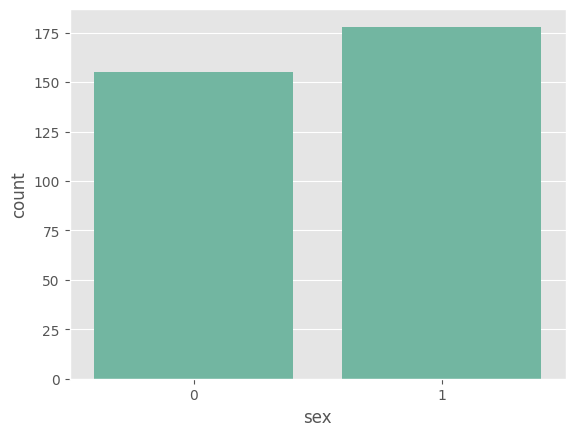

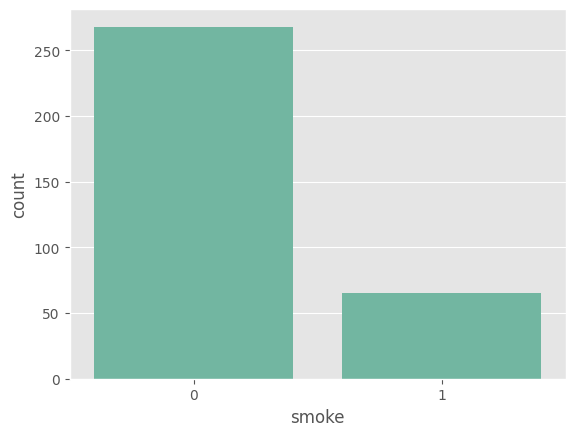

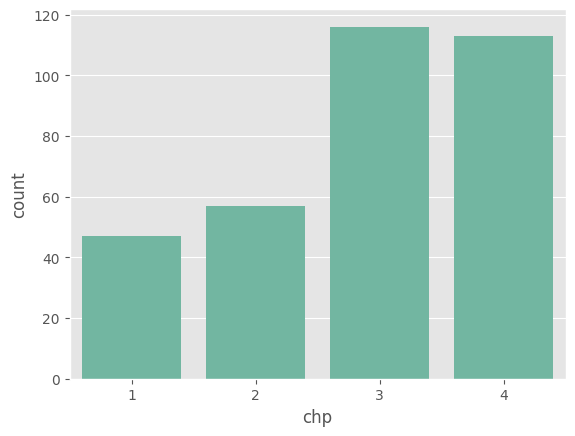

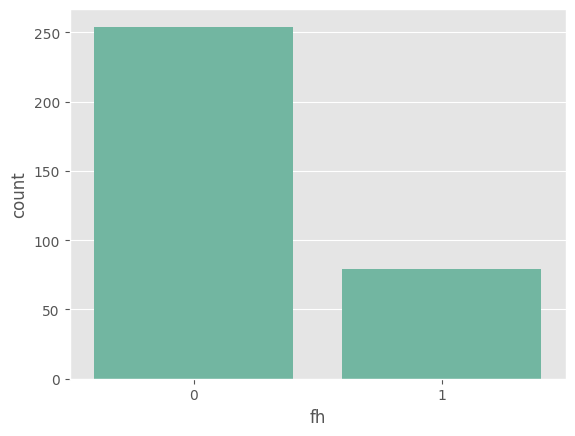

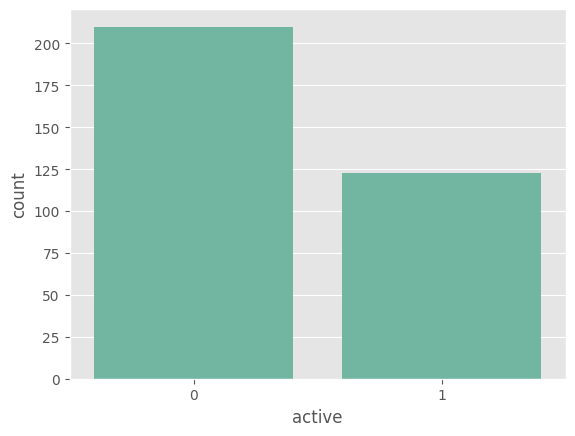

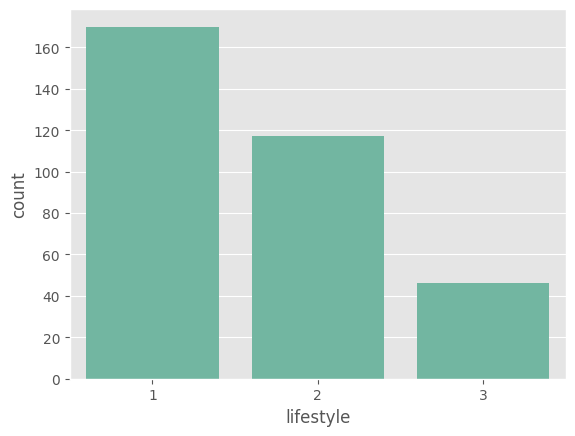

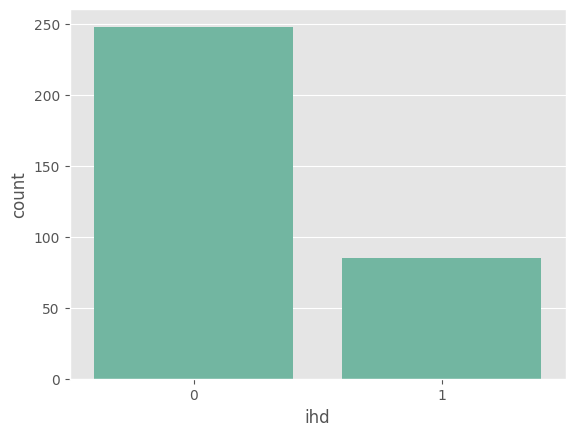

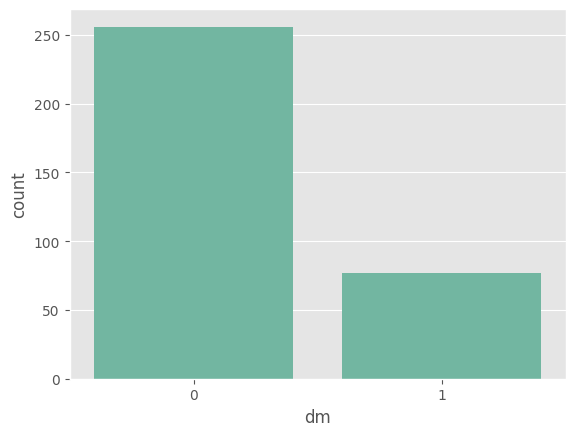

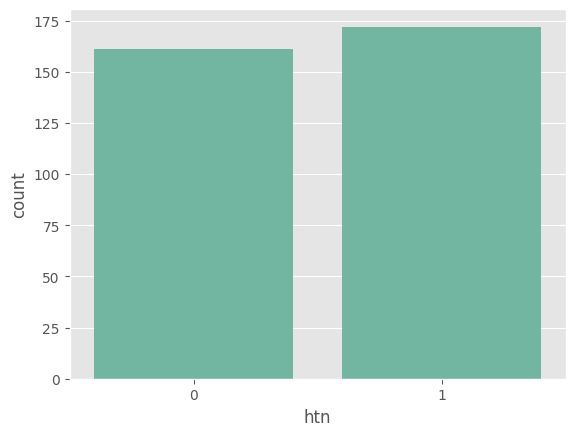

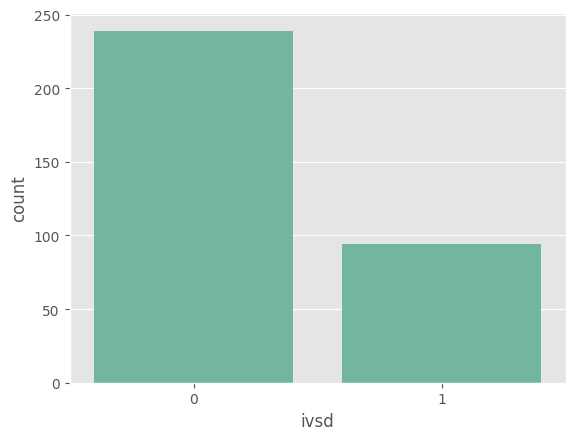

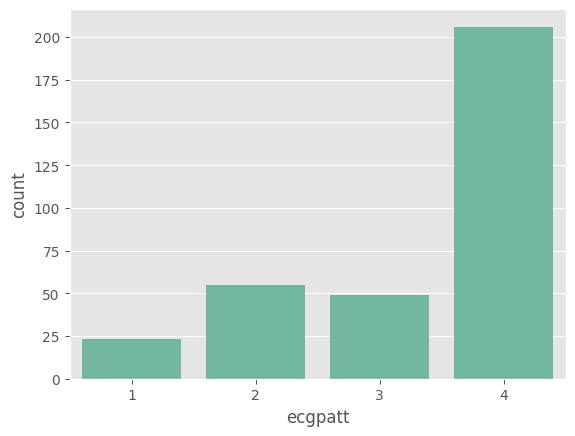

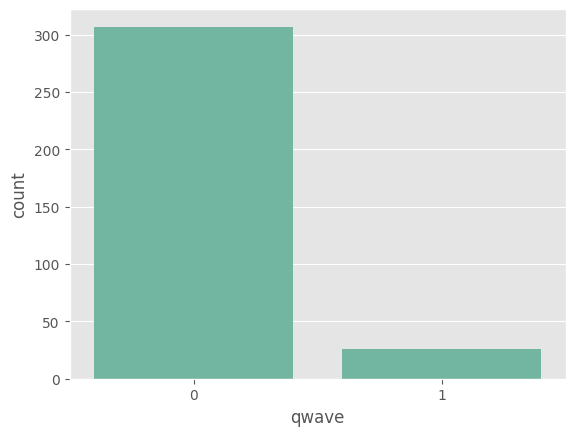

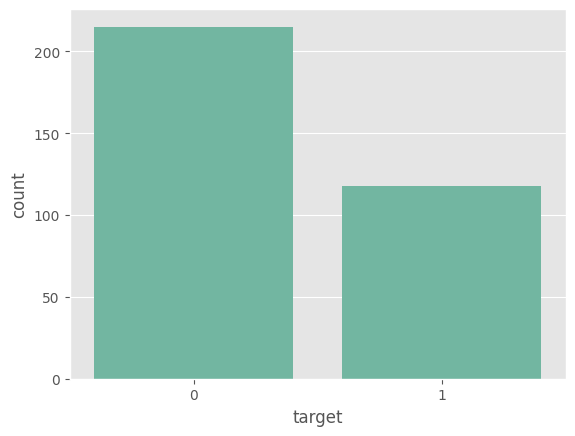

In [ ]:
for col in cat_cols:
  sns.countplot(data=df,x=col)
  plt.show()

In [ ]:
cat_cols

['sex',
 'smoke',
 'chp',
 'fh',
 'active',
 'lifestyle',
 'ihd',
 'dm',
 'htn',
 'ivsd',
 'ecgpatt',
 'qwave',
 'target']

In [ ]:
for col in cat_cols:
  print("Value Count for Column ",col)
  print(df[col].value_counts())
  print('*'*100)

Value Count for Column  sex
sex
1    178
0    155
Name: count, dtype: int64
****************************************************************************************************
Value Count for Column  smoke
smoke
0    268
1     65
Name: count, dtype: int64
****************************************************************************************************
Value Count for Column  chp
chp
3    116
4    113
2     57
1     47
Name: count, dtype: int64
****************************************************************************************************
Value Count for Column  fh
fh
0    254
1     79
Name: count, dtype: int64
****************************************************************************************************
Value Count for Column  active
active
0    210
1    123
Name: count, dtype: int64
****************************************************************************************************
Value Count for Column  lifestyle
lifestyle
1    170
2    117
3     46
Name: count, dtype

#PHASE 2 — In-Depth Exploratory Data Analysis (EDA)

##Task 3: Univariate analysis


In [ ]:
cat_cols

['sex',
 'smoke',
 'chp',
 'fh',
 'active',
 'lifestyle',
 'ihd',
 'dm',
 'htn',
 'ivsd',
 'ecgpatt',
 'qwave',
 'target']

In [ ]:
df.columns

Index(['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'target'],
      dtype='object')

In [ ]:
num_cols = list(set(df.columns)-set(cat_cols))
num_cols

['height', 'weight', 'hr', 'bpsys', 'years', 'bpdias', 'ldl', 'age']

In [ ]:
df[num_cols].mean(axis=0)

,0
height,162.102102
weight,82.157357
hr,83.882883
bpsys,123.618619
years,4.798799
bpdias,74.879880
ldl,112.926246
age,55.117117


In [ ]:
df[num_cols].std(axis=0)

,0
height,11.295127
weight,15.392197
hr,14.633107
bpsys,21.341639
years,11.249835
bpdias,12.681834
ldl,37.972983
age,14.159210


In [ ]:
df[num_cols].agg(['mean','std'])

,height,weight,hr,bpsys,years,bpdias,ldl,age
mean,162.102102,82.157357,83.882883,123.618619,4.798799,74.879880,112.926246,55.117117
std,11.295127,15.392197,14.633107,21.341639,11.249835,12.681834,37.972983,14.159210


In [ ]:
num_cols

['height', 'weight', 'hr', 'bpsys', 'years', 'bpdias', 'ldl', 'age']

In [ ]:
df[num_cols].skew()

,0
height,-0.104087
weight,0.484253
hr,0.424751
bpsys,0.907256
years,2.396320
bpdias,0.617669
ldl,0.444806
age,-0.132801


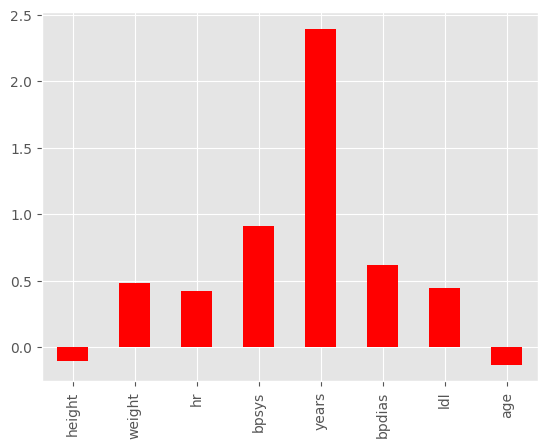

In [ ]:
df[num_cols].skew().plot(kind='bar',color='r')
plt.show()

- skewness exists highy in years and moderately in bpsys and weakly in bpdias

In [ ]:
df[num_cols].kurtosis()

,0
height,-0.522788
weight,0.864249
hr,0.848824
bpsys,1.492057
years,4.817345
bpdias,2.004322
ldl,0.283304
age,-0.697336


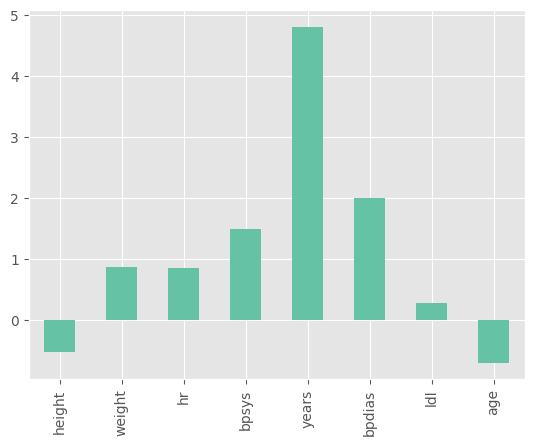

In [ ]:
df[num_cols].kurtosis().plot(kind='bar')
plt.show()

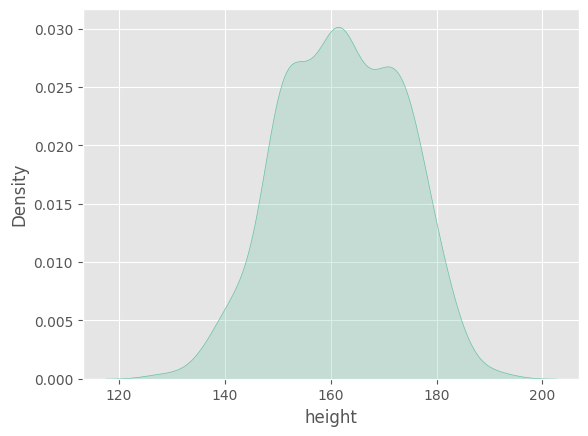

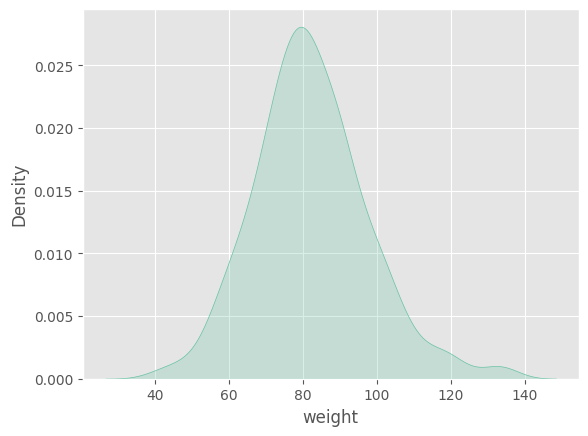

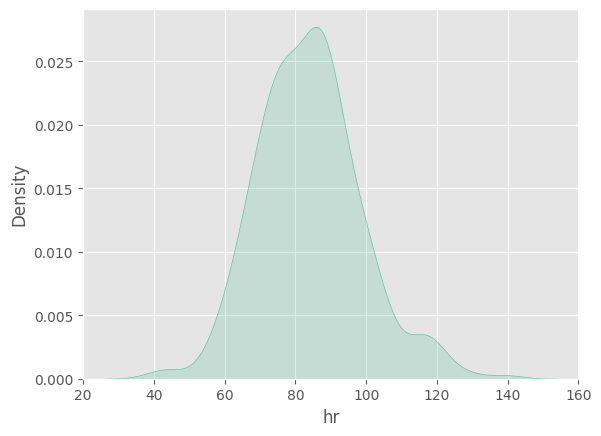

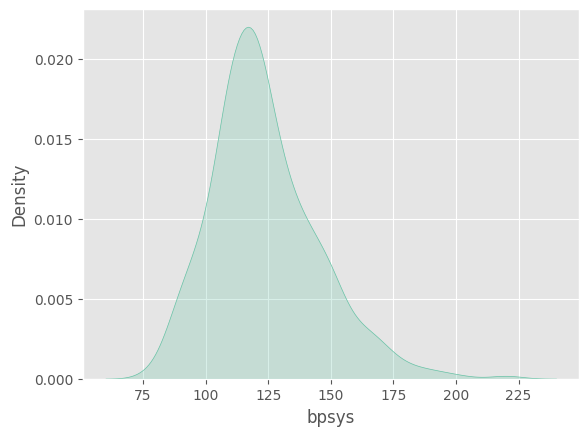

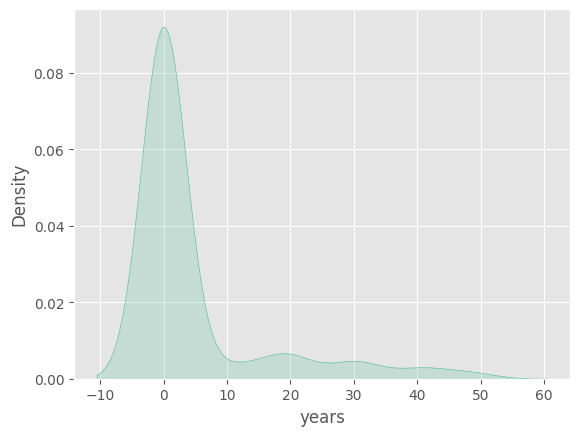

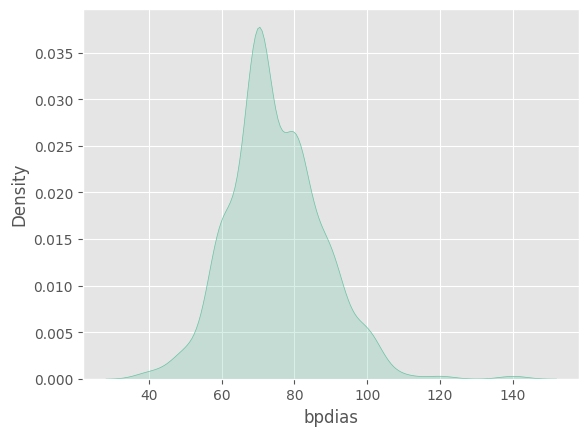

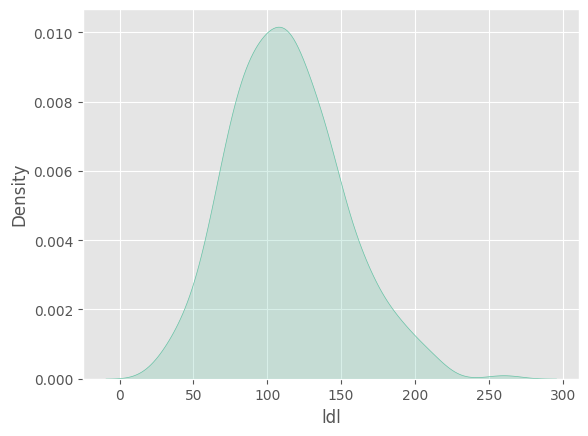

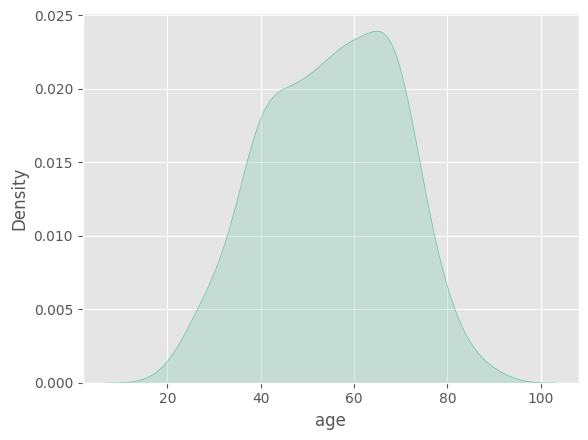

In [ ]:
for col in num_cols:
  sns.kdeplot(df[col],fill=True)
  plt.show()

In [ ]:
df[num_cols].skew()

,0
height,-0.104087
weight,0.484253
hr,0.424751
bpsys,0.907256
years,2.396320
bpdias,0.617669
ldl,0.444806
age,-0.132801


#Lets fix the skewness

In [ ]:
#Using Yeo Johnson

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

#df['bpsys'] = pt.fit_transform(df[['bpsys']])
#df['bpdias'] = pt.fit_transform(df[['bpdias']])


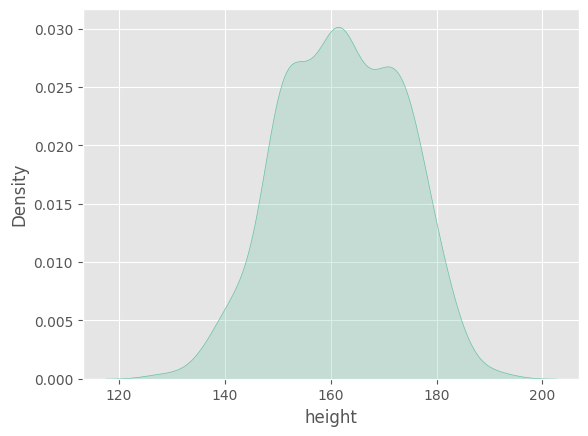

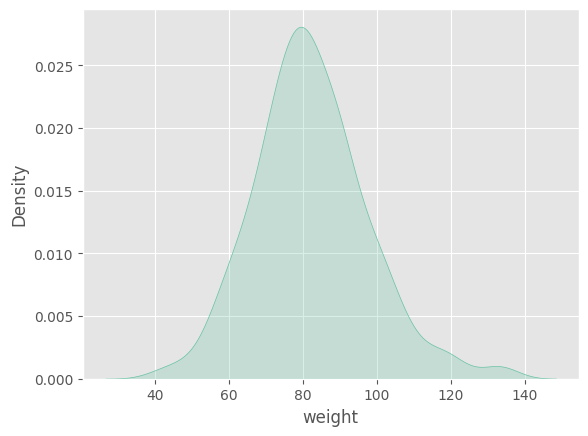

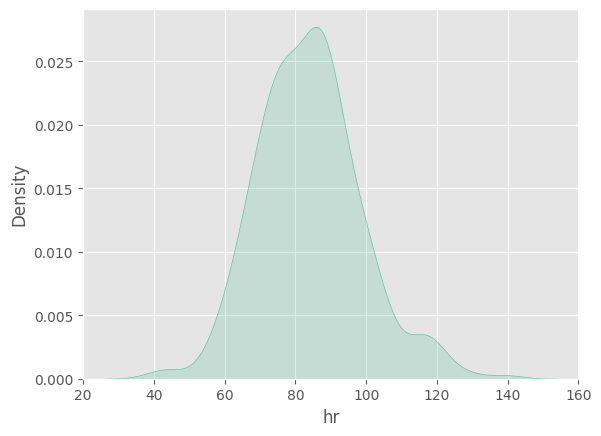

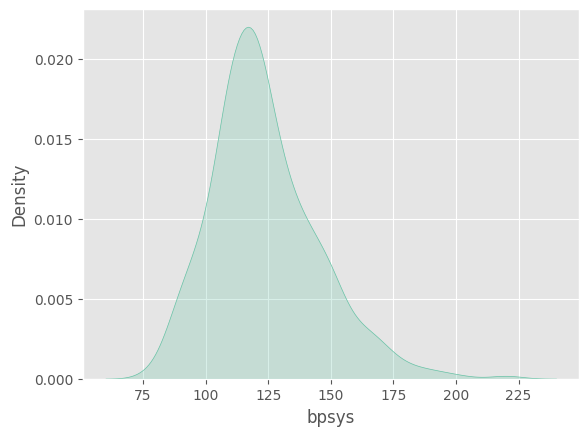

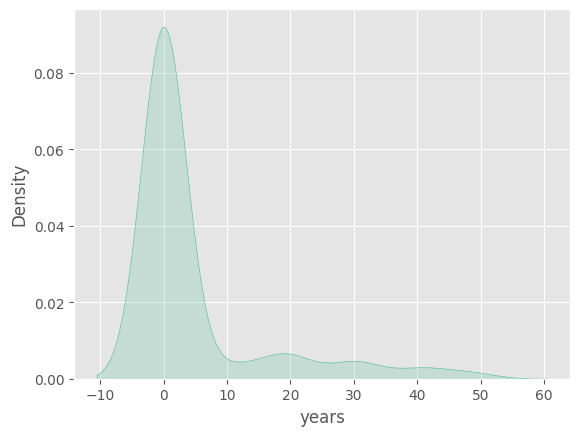

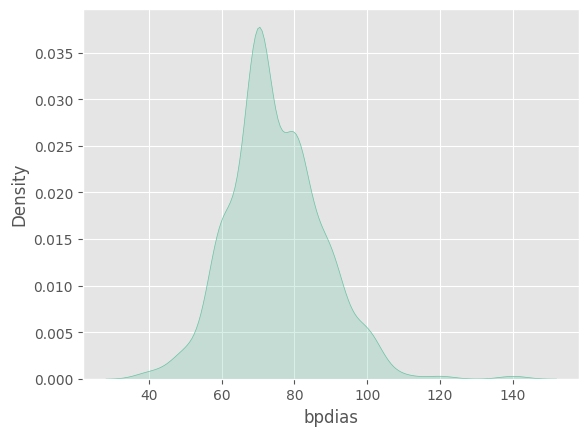

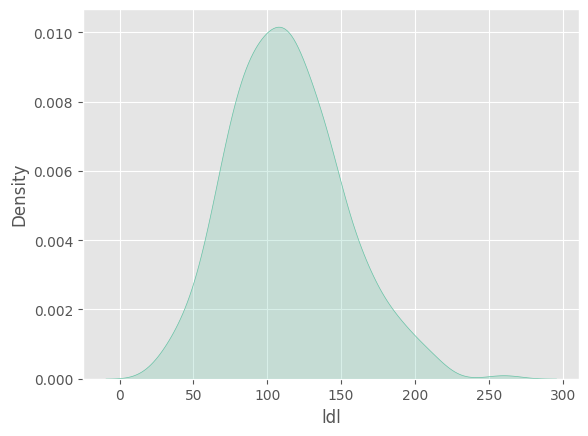

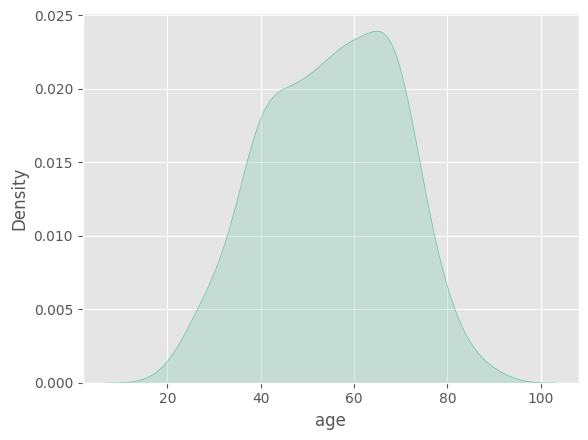

In [ ]:
for col in num_cols:
  sns.kdeplot(df[col],fill=True)
  plt.show()

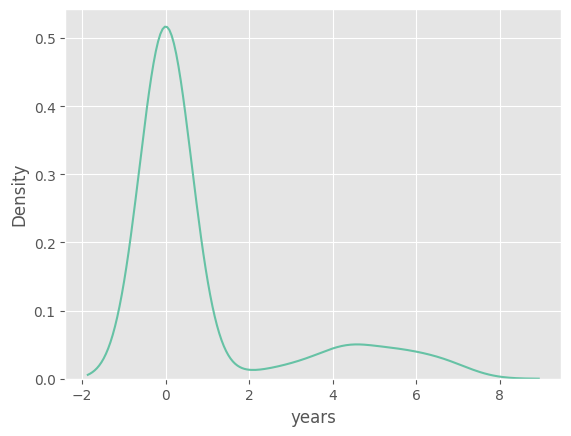

In [ ]:
sns.kdeplot((df['years'])**(1/2))
plt.show()

In [ ]:
df.head()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,ihd,hr,dm,bpsys,bpdias,htn,ivsd,ecgpatt,qwave,target
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,98,1,120,80,1,0,4,0,0
1,54,1,0,0,117.0,2,145,81.0,0,0,...,0,85,0,130,80,0,0,4,0,0
2,61,0,1,45,86.2,2,160,72.0,0,0,...,0,63,1,150,70,1,0,2,0,1
3,57,0,0,0,76.0,2,176,78.0,1,0,...,1,74,1,120,70,0,0,3,0,1
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,89,1,110,70,0,0,1,0,1


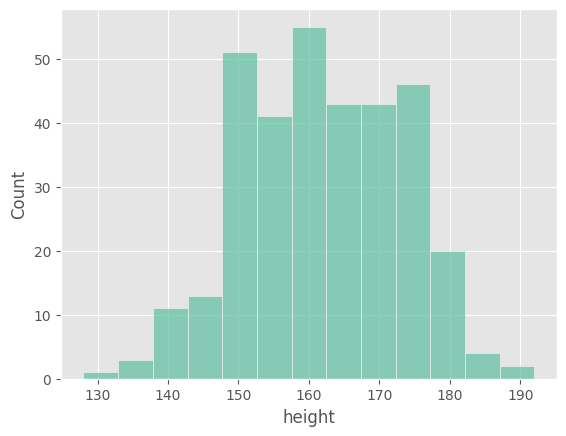

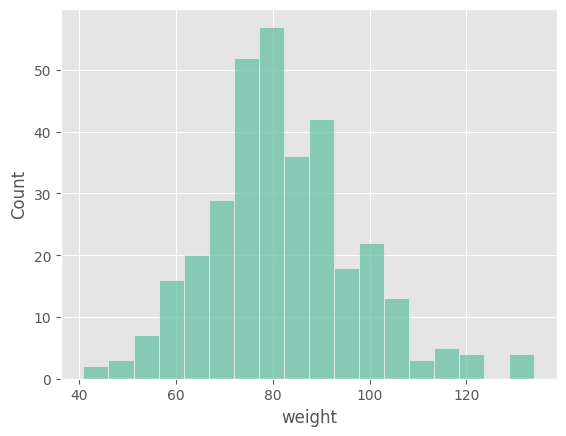

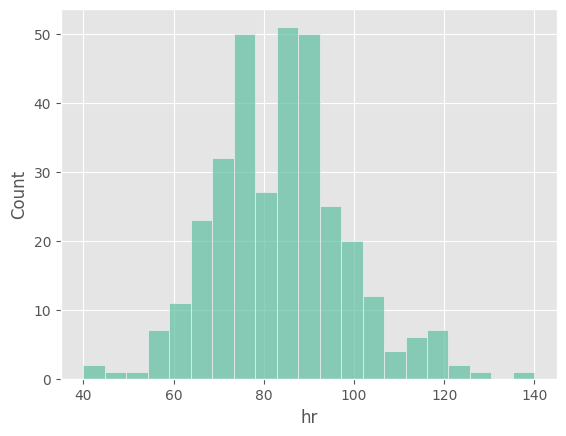

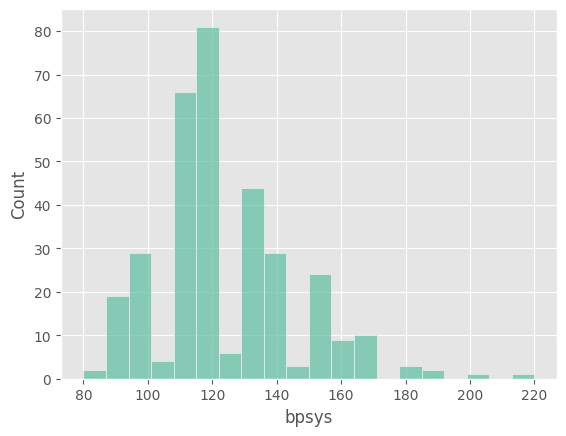

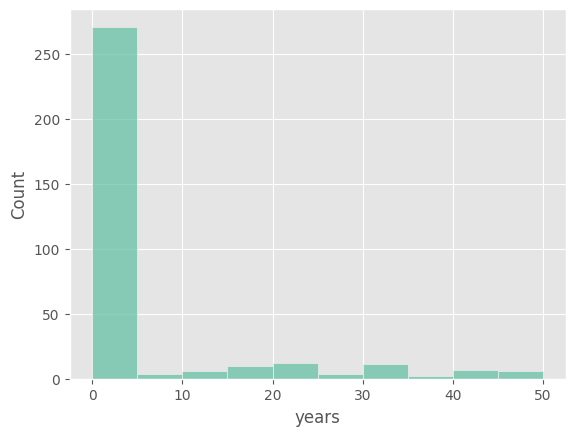

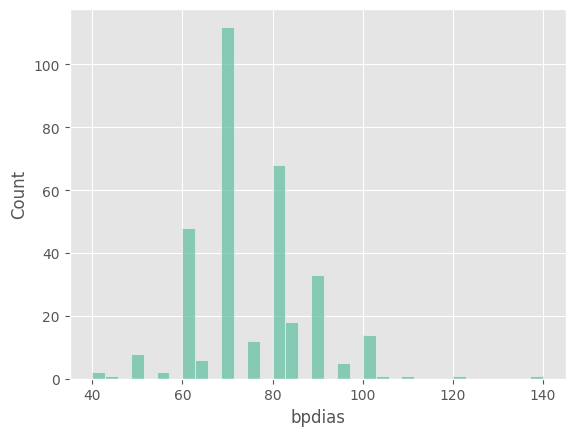

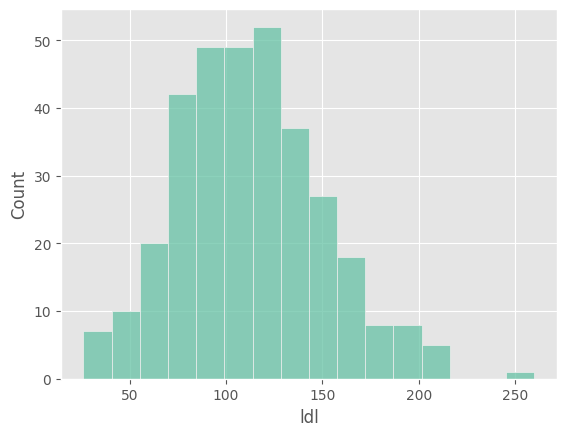

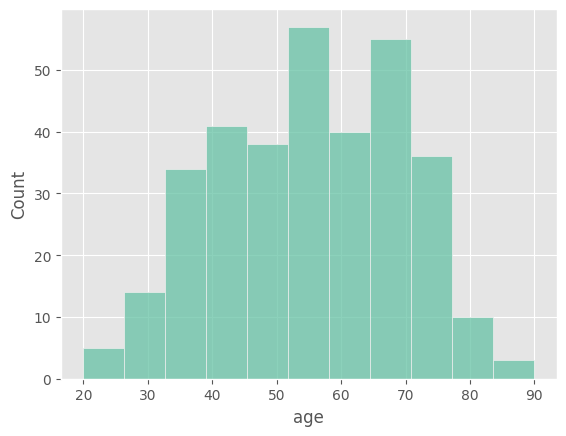

In [ ]:
for col in num_cols:
  sns.histplot(df[col])
  plt.show()

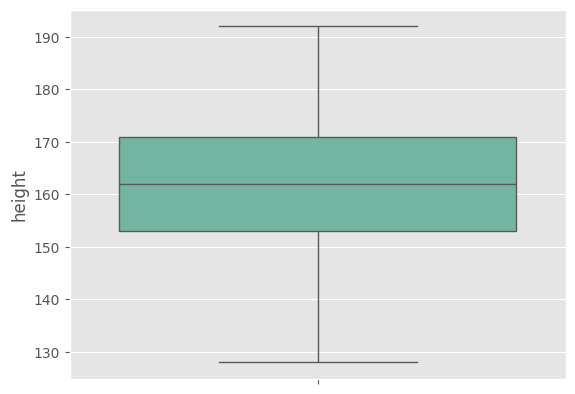

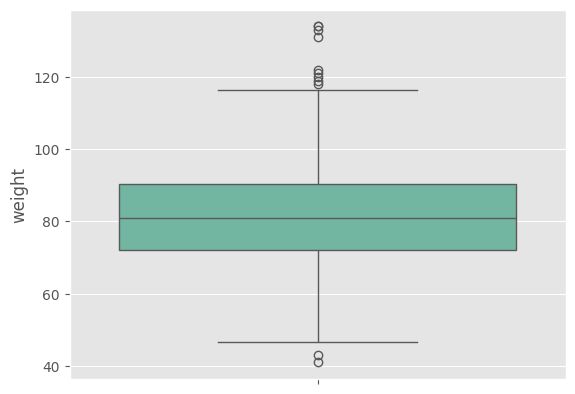

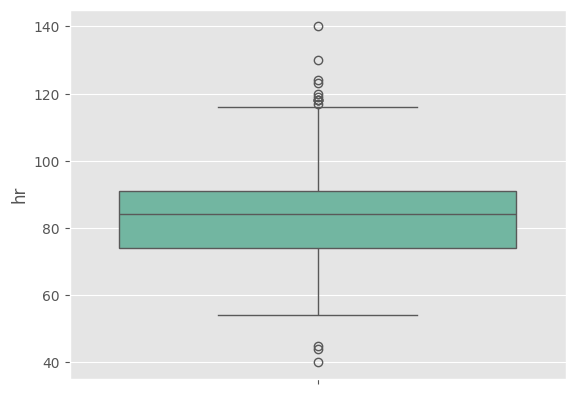

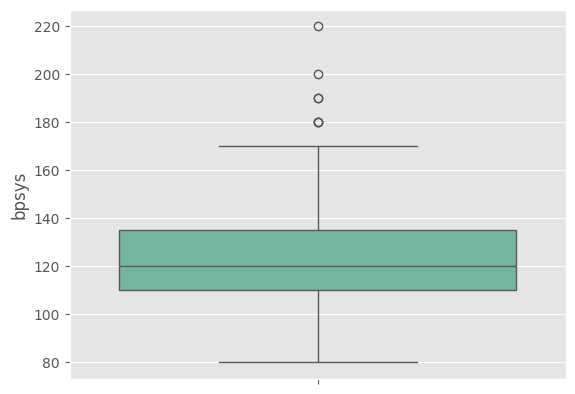

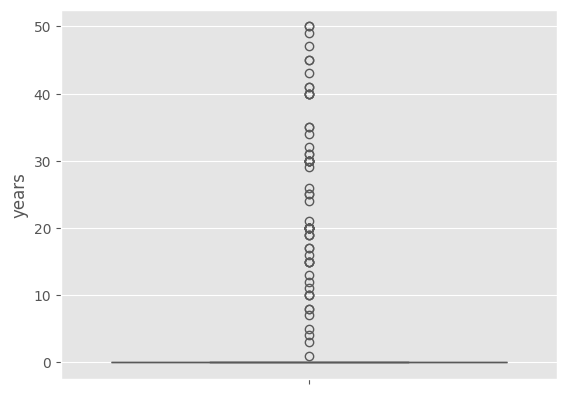

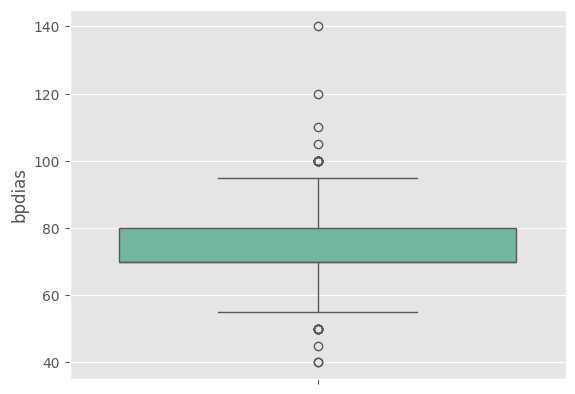

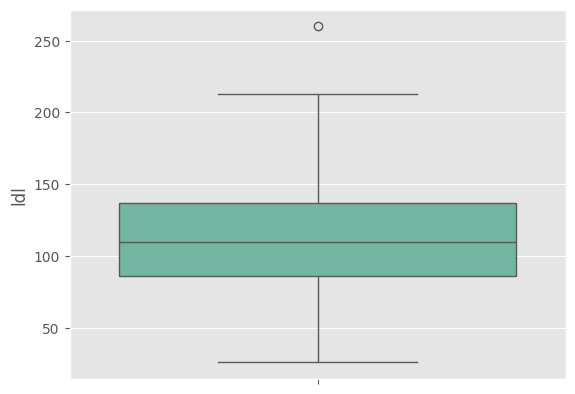

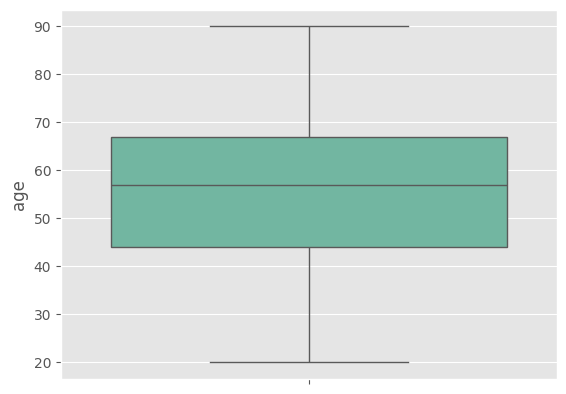

In [ ]:
for col in num_cols:
  sns.boxplot(df[col])
  plt.show()

In [ ]:
df['target'].value_counts()

,count
target,
0,215
1,118


- the target is imbalanced

#Task 4: Bivariate analysis (feature → target relationships)

- Compare distributions of each numeric feature across target classes

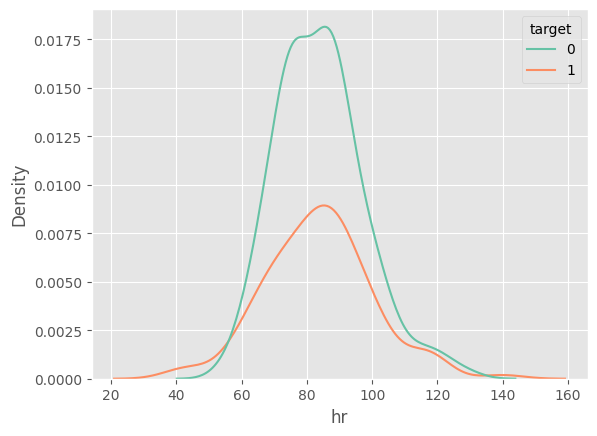

In [ ]:
sns.kdeplot(data=df,x = 'hr',hue='target')
plt.show()

- from the above graph we can see that people who are having heart disease also tend to have low hr and also some have very unusual high hr

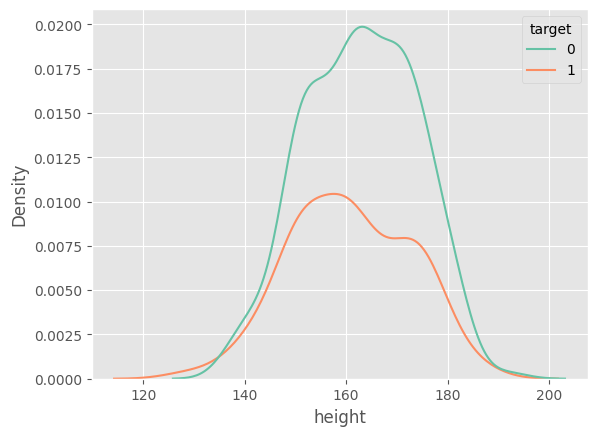

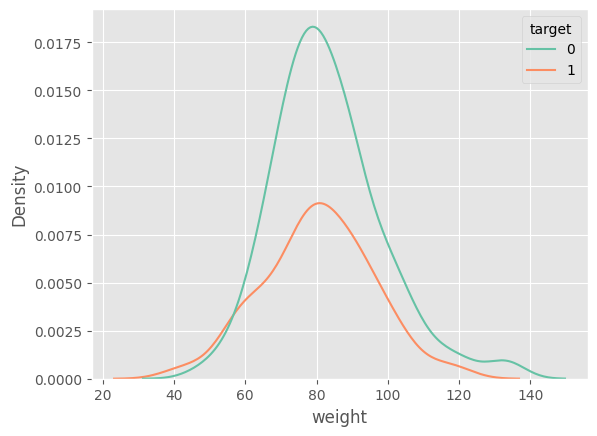

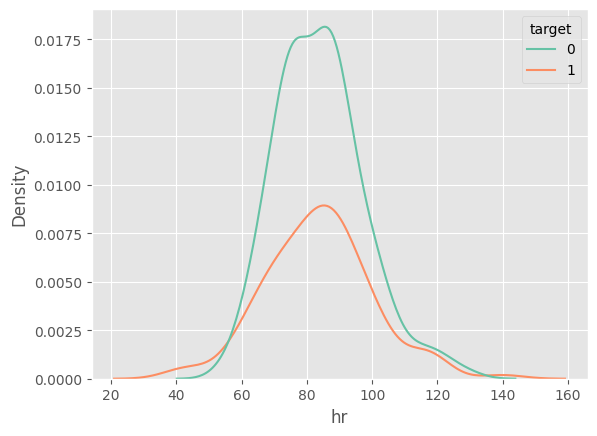

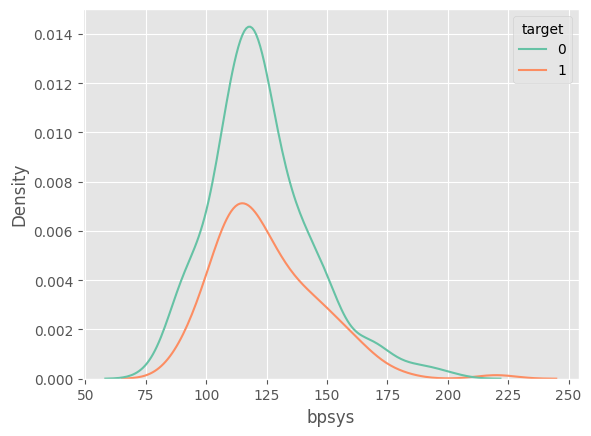

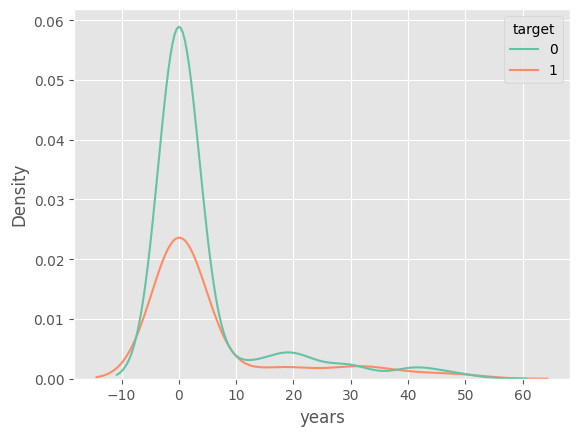

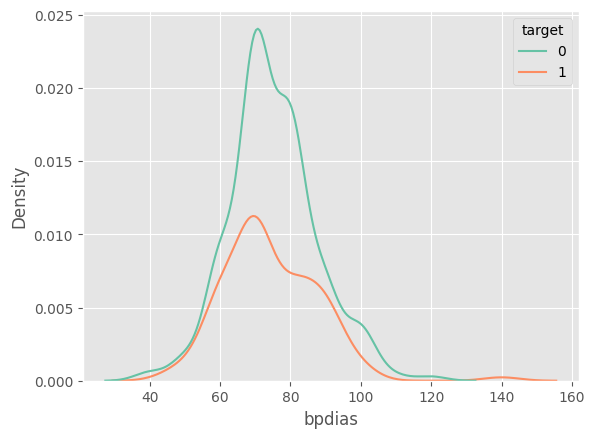

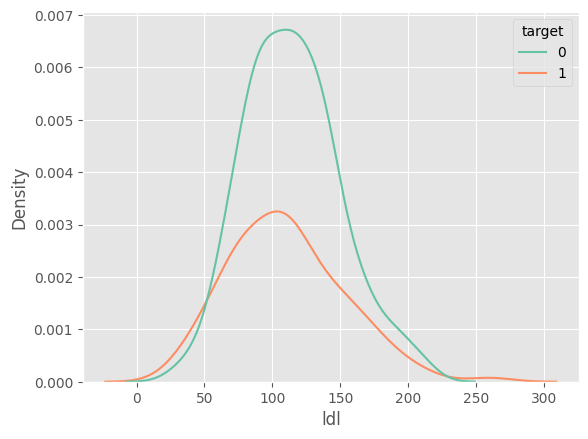

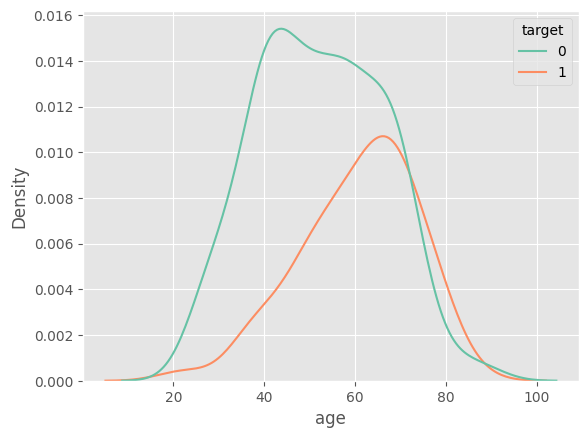

In [ ]:
for col in num_cols:
  sns.kdeplot(data=df,x = col,hue='target')
  plt.show()

In [ ]:
df.head()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,ihd,hr,dm,bpsys,bpdias,htn,ivsd,ecgpatt,qwave,target
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,98,1,120,80,1,0,4,0,0
1,54,1,0,0,117.0,2,145,81.0,0,0,...,0,85,0,130,80,0,0,4,0,0
2,61,0,1,45,86.2,2,160,72.0,0,0,...,0,63,1,150,70,1,0,2,0,1
3,57,0,0,0,76.0,2,176,78.0,1,0,...,1,74,1,120,70,0,0,3,0,1
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,89,1,110,70,0,0,1,0,1


#Study ECG pattern contribution to disease occurrence


In [ ]:
pd.crosstab(df['ecgpatt'],df['target'])

target,0,1
ecgpatt,,
1,8,15
2,3,52
3,1,48
4,203,3


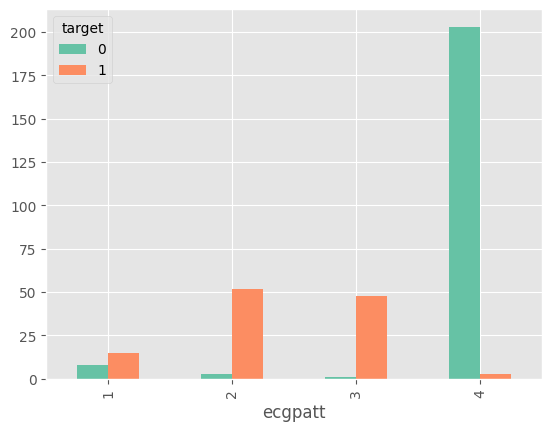

In [ ]:
pd.crosstab(df['ecgpatt'],df['target']).plot(kind='bar')
plt.show()

In [ ]:
df.groupby(['ecgpatt'])['target'].mean()*100

,target
ecgpatt,
1,65.217391
2,94.545455
3,97.959184
4,1.456311


In [ ]:
df.columns

Index(['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'target'],
      dtype='object')

#Task 5: Multivariate analysis

● Compute correlations among numeric features

● Generate Pearson heatmap


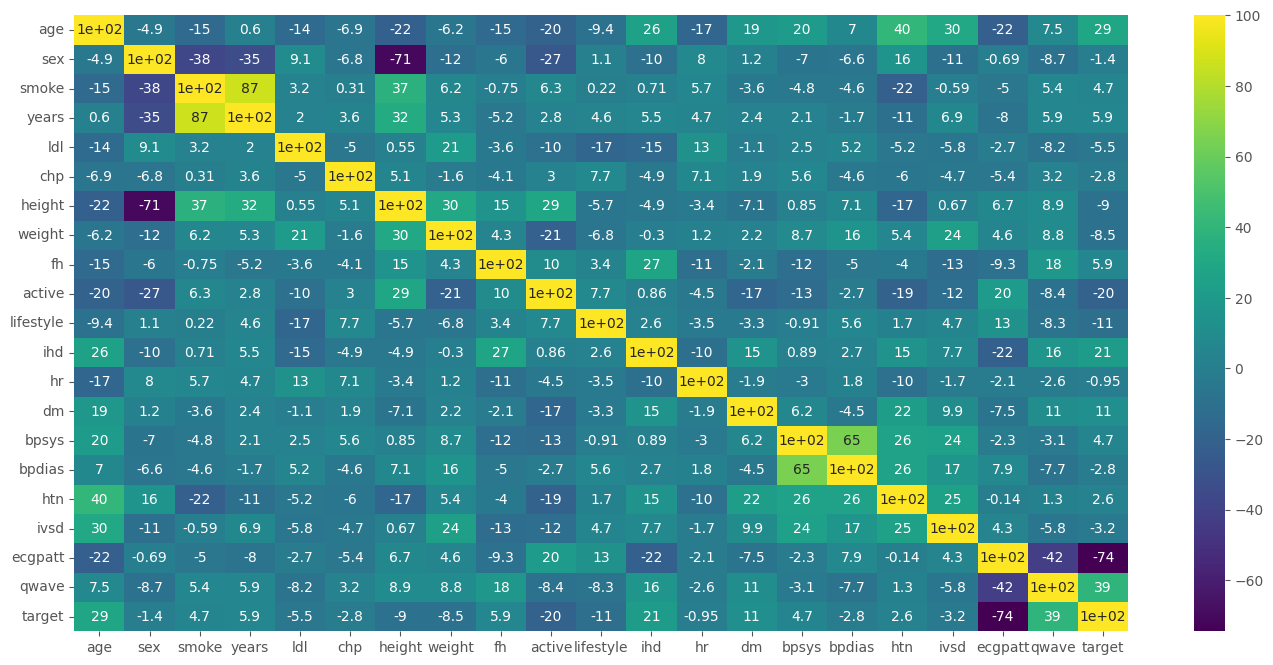

In [ ]:
plt.figure(figsize=(17,8))
sns.heatmap(df.corr()*100,annot=True,cmap='viridis')
plt.show()

In [ ]:
pearson_corr = (df.corr()['target']*100).reset_index().loc[0:19]
pearson_corr

,index,target
0,age,28.650673
1,sex,-1.353153
2,smoke,4.699727
3,years,5.854185
4,ldl,-5.503464
5,chp,-2.762481
6,height,-8.965142
7,weight,-8.475078
8,fh,5.912419
9,active,-20.274256


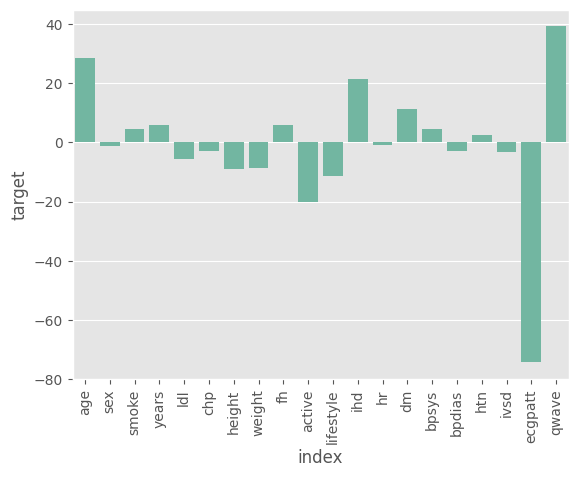

In [ ]:
sns.barplot(x = pearson_corr['index'],y=pearson_corr['target'])
plt.xticks(rotation=90)
plt.show()

- we can see that the ecgpatt has the highest amount of correlation its negative that means as the ecgpatt goes down the target goes up

#PHASE 3 — Statistical Testing & Hypothesis Validation


- Task 6: Continuous vs Target (binary)

In [ ]:
#target is binary

#we need to run tests to compare numerical values with the target

num_cols

['height', 'weight', 'hr', 'bpsys', 'years', 'bpdias', 'ldl', 'age']

#Using Point Biserial Correlation

In [ ]:
#age vs target

#H0:There is no impact of age on the target
#H1:There is a significant impact of age on the target

from scipy.stats import pointbiserialr as pb

pb(df['age'],df['target'])

SignificanceResult(statistic=np.float64(0.28650673347225825), pvalue=np.float64(1.0345560447191079e-07))

- the p value < 0.05 so we reject H0 and accept H1

In [ ]:

for col in num_cols:
  corr,p = pb(df[col],df['target'])
  print(f'{col} vs target : Correlation:{corr}   P_Value:{p}')

height vs target : Correlation:-0.08965141924322663   P_Value:0.10244308357444239
weight vs target : Correlation:-0.08475077685556465   P_Value:0.12270483145310322
hr vs target : Correlation:-0.009530624850603998   P_Value:0.8624411336949257
bpsys vs target : Correlation:0.04655114983924534   P_Value:0.39713802640098234
years vs target : Correlation:0.05854185360858188   P_Value:0.2867920735995516
bpdias vs target : Correlation:-0.027678716674791503   P_Value:0.6147629571910457
ldl vs target : Correlation:-0.05503463622478331   P_Value:0.3166960425315758
age vs target : Correlation:0.28650673347225825   P_Value:1.0345560447191079e-07


| Feature    | Correlation | P-Value         | Significant? |
| ---------- | ----------- | --------------- | ------------ |
| **years**  | 0.05854     | 0.28679         | ❌ No         |
| **height** | -0.08965    | 0.10244         | ❌ No         |
| **weight** | -0.08475    | 0.12270         | ❌ No         |
| **age**    | **0.28651** | **1.03 × 10⁻⁷** | ✅ **Yes**    |
| **hr**     | -0.00953    | 0.86244         | ❌ No         |
| **ldl**    | -0.05503    | 0.31670         | ❌ No         |
| **bpsys**  | 0.05175     | 0.34644         | ❌ No         |
| **bpdias** | -0.03237    | 0.55610         | ❌ No         |


#Task 7: Categorical vs Target

In [ ]:
cat_cols.remove('target')

In [ ]:
cat_cols

['sex',
 'smoke',
 'chp',
 'fh',
 'active',
 'lifestyle',
 'ihd',
 'dm',
 'htn',
 'ivsd',
 'ecgpatt',
 'qwave']

In [ ]:
from scipy.stats import chi2_contingency

#H0:There is no association between smoke and target
#H1:There is a significant association between smoke and target

ct = pd.crosstab(df['smoke'],df['target'])
chi2_contingency(ct)

Chi2ContingencyResult(statistic=np.float64(0.5084997586805969), pvalue=np.float64(0.47578902122701283), dof=1, expected_freq=array([[173.03303303,  94.96696697],
       [ 41.96696697,  23.03303303]]))

In [ ]:
for col in cat_cols:
  ct = pd.crosstab(df[col],df['target'])
  p = chi2_contingency(ct)[1]
  print(f'{col} vs target : P_Value:{p}')

sex vs target : P_Value:0.8949167449260182
smoke vs target : P_Value:0.47578902122701283
chp vs target : P_Value:0.433004590493248
fh vs target : P_Value:0.3450403827307489
active vs target : P_Value:0.00034226257983875055
lifestyle vs target : P_Value:0.006758252424936328
ihd vs target : P_Value:0.00015773923347873892
dm vs target : P_Value:0.049941021680311046
htn vs target : P_Value:0.7221442555203924
ivsd vs target : P_Value:0.6451372656290573
ecgpatt vs target : P_Value:1.5745013909524498e-60
qwave vs target : P_Value:3.5302163290861423e-12


| Feature       | P-Value      | Significant?           |
| ------------- | ------------ | ---------------------- |
| **sex**       | 0.89492      | ❌ No                   |
| **smoke**     | 0.47579      | ❌ No                   |
| **chp**       | 0.43300      | ❌ No                   |
| **fh**        | 0.34504      | ❌ No                   |
| **active**    | 0.0003423    | ✅ **Yes**              |
| **lifestyle** | 0.006758     | ✅ **Yes**              |
| **ihd**       | 0.0001577    | ✅ **Yes**              |
| **dm**        | 0.04994      | ✅ **Yes** (borderline) |
| **htn**       | 0.72214      | ❌ No                   |
| **ivsd**      | 0.64514      | ❌ No                   |
| **ecgpatt**   | 1.57 × 10⁻⁶⁰ | ✅ **Yes**              |
| **qwave**     | 3.53 × 10⁻¹² | ✅ **Yes**              |


Task 8: Continuous vs Categorical (>2 groups)

In [ ]:
num_cols

['height', 'weight', 'hr', 'bpsys', 'years', 'bpdias', 'ldl', 'age']

In [ ]:
cat_cols

['sex',
 'smoke',
 'chp',
 'fh',
 'active',
 'lifestyle',
 'ihd',
 'dm',
 'htn',
 'ivsd',
 'ecgpatt',
 'qwave']

In [ ]:
mcv = []
for col in cat_cols:
  if len(df[col].unique())>2:
    mcv.append(col)

mcv

['chp', 'lifestyle', 'ecgpatt']

#LDL VS BP

In [ ]:
df.head()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,ihd,hr,dm,bpsys,bpdias,htn,ivsd,ecgpatt,qwave,target
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,98,1,120,80,1,0,4,0,0
1,54,1,0,0,117.0,2,145,81.0,0,0,...,0,85,0,130,80,0,0,4,0,0
2,61,0,1,45,86.2,2,160,72.0,0,0,...,0,63,1,150,70,1,0,2,0,1
3,57,0,0,0,76.0,2,176,78.0,1,0,...,1,74,1,120,70,0,0,3,0,1
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,89,1,110,70,0,0,1,0,1


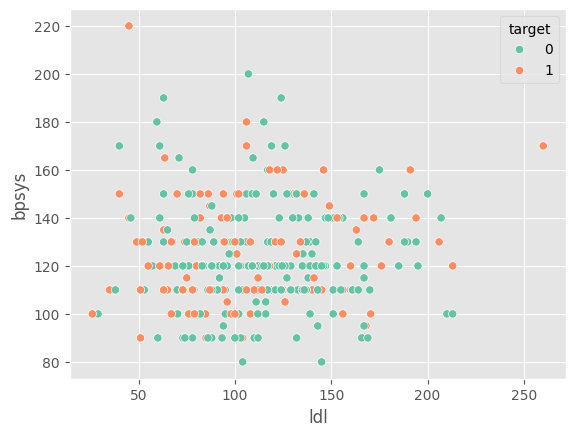

In [ ]:
sns.scatterplot(data=df,x = 'ldl',y = 'bpsys',hue='target')
plt.show()

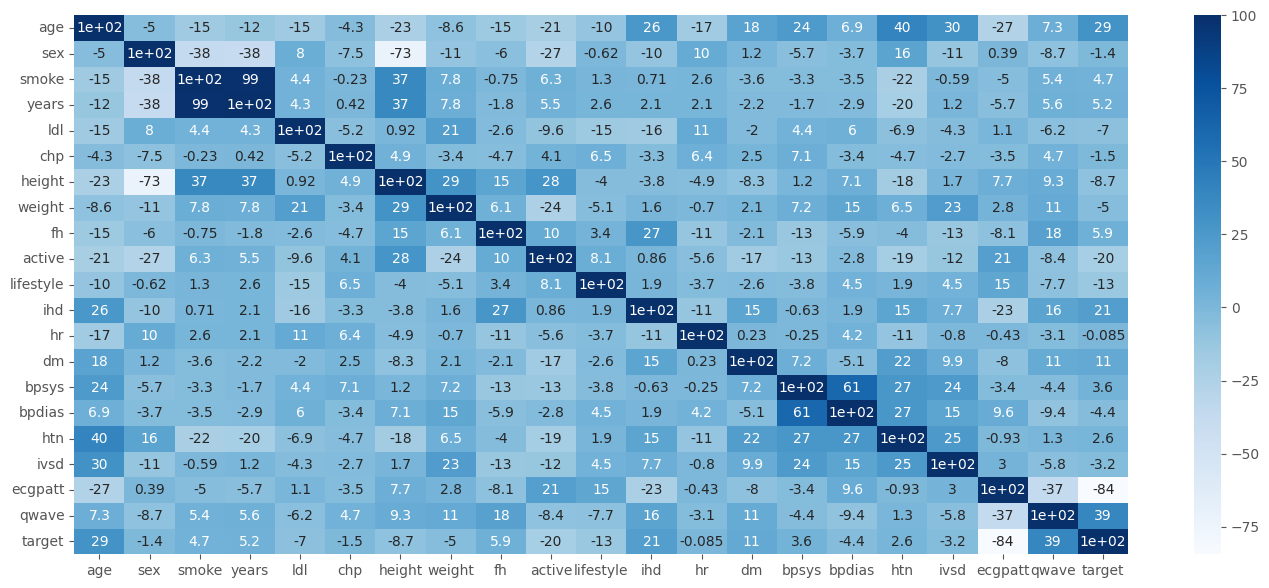

In [ ]:
plt.figure(figsize=(17,7))
sns.heatmap(df.corr(method='spearman')*100,annot=True,cmap='Blues')
plt.show()

#Feature Engineering

In [ ]:
import numpy as np

# 1. BMI
df["BMI"] = df["weight"] / (df["height"] / 100) ** 2

# 2. Pulse Pressure
df["pulse_pressure"] = df["bpsys"] - df["bpdias"]

# 3. Mean Arterial Pressure (MAP)
df["MAP"] = (df["bpsys"] + 2 * df["bpdias"]) / 3

# 4. Smoking Exposure Index
df["smoke_exposure"] = df["smoke"] * df["years"]

# 5. LDL / Age Ratio
df["ldl_age_ratio"] = df["ldl"] / df["age"]

# 6. LDL × Smoking Interaction
df["ldl_smoke_interaction"] = df["ldl"] * df["smoke"]

# 7. Obesity Flag
df["obese"] = (df["BMI"] >= 30).astype(int)

# 8. BP Category
def bp_category(row):
    s, d = row["bpsys"], row["bpdias"]
    if s >= 140 or d >= 90:
        return 3   # Hypertension stage
    elif s >= 130 or d >= 85:
        return 2   # Prehypertension
    elif s >= 120:
        return 1   # Elevated
    else:
        return 0   # Normal

df["bp_category"] = df.apply(bp_category, axis=1)

# 9. Heart Rate Risk Flag
df["hr_risk"] = (df["hr"] > 90).astype(int)

# 10. Diabetes × LDL Interaction
df["dm_ldl_interaction"] = df["dm"] * df["ldl"]

# 11. Active × Lifestyle Combined Score
df["active_lifestyle_interaction"] = df["active"] * df["lifestyle"]

# 12. IVSD Risk (if numeric values exist)
# If ivsd is already 0/1, this will just copy it.
df["ivsd_risk"] = (df["ivsd"] > 0).astype(int)

# 13. ECG Pattern Risk (assuming values 1–4)
df["ecg_major_abnormal"] = df["ecgpatt"].isin([3, 4]).astype(int)
df["ecg_mild_abnormal"] = df["ecgpatt"].isin([1, 2]).astype(int)

# 14. Atherogenic Index (log)
df["atherogenic_index"] = np.log((df["ldl"] + 1) / (df["chp"] + 1))

# 15. Smoking × Blood Pressure Interaction
df["smoke_bpsys_interaction"] = df["smoke"] * df["bpsys"]

# 17. Metabolic Syndrome Score
df["metabolic_syndrome_score"] = (
    (df["BMI"] >= 25).astype(int)
    + (df["bpsys"] > 130).astype(int)
    + (df["ldl"] > 100).astype(int)
    + df["dm"]
)


In [ ]:
df['bpsys']

,bpsys
0,120
1,130
2,150
3,120
4,110
...,...
328,150
329,110
330,105
331,110


In [ ]:
df.head()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,bp_category,hr_risk,dm_ldl_interaction,active_lifestyle_interaction,ivsd_risk,ecg_major_abnormal,ecg_mild_abnormal,atherogenic_index,smoke_bpsys_interaction,metabolic_syndrome_score
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,1,69.0,0,0,1,0,2.639057,0,2
1,54,1,0,0,117.0,2,145,81.0,0,0,...,2,0,0.0,0,0,1,0,3.672072,0,2
2,61,0,1,45,86.2,2,160,72.0,0,0,...,3,0,86.2,0,0,0,1,3.369592,150,3
3,57,0,0,0,76.0,2,176,78.0,1,0,...,1,0,76.0,0,0,1,0,3.245193,0,2
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,0,160.0,0,0,0,1,3.695110,0,3


In [ ]:
df.isna().sum()

,0
age,0
sex,0
smoke,0
years,0
ldl,0
chp,0
height,0
weight,0
fh,0
active,0


In [ ]:
df.columns

Index(['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'target', 'BMI', 'pulse_pressure', 'MAP',
       'smoke_exposure', 'ldl_age_ratio', 'ldl_smoke_interaction', 'obese',
       'bp_category', 'hr_risk', 'dm_ldl_interaction',
       'active_lifestyle_interaction', 'ivsd_risk', 'ecg_major_abnormal',
       'ecg_mild_abnormal', 'atherogenic_index', 'smoke_bpsys_interaction',
       'metabolic_syndrome_score'],
      dtype='object')

In [ ]:
df = df[['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'BMI', 'pulse_pressure', 'MAP',
       'smoke_exposure', 'ldl_age_ratio', 'ldl_smoke_interaction', 'obese',
       'bp_category', 'hr_risk', 'dm_ldl_interaction',
       'active_lifestyle_interaction', 'ivsd_risk', 'ecg_major_abnormal',
       'ecg_mild_abnormal', 'atherogenic_index', 'smoke_bpsys_interaction',
       'metabolic_syndrome_score', 'target']]

df.head()

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,hr_risk,dm_ldl_interaction,active_lifestyle_interaction,ivsd_risk,ecg_major_abnormal,ecg_mild_abnormal,atherogenic_index,smoke_bpsys_interaction,metabolic_syndrome_score,target
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,69.0,0,0,1,0,2.639057,0,2,0
1,54,1,0,0,117.0,2,145,81.0,0,0,...,0,0.0,0,0,1,0,3.672072,0,2,0
2,61,0,1,45,86.2,2,160,72.0,0,0,...,0,86.2,0,0,0,1,3.369592,150,3,1
3,57,0,0,0,76.0,2,176,78.0,1,0,...,0,76.0,0,0,1,0,3.245193,0,2,1
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,160.0,0,0,0,1,3.695110,0,3,1


In [ ]:
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.645646
1,0.354354


#PHASE 6 — Model Development

In [ ]:
x = df.iloc[:,:-1]
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y)
x_train.shape

(266, 37)

In [ ]:
y_train.shape

(266,)

In [ ]:
x_test.shape

(67, 37)

In [ ]:
y_test.shape

(67,)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
target,
0,0.646617
1,0.353383


In [ ]:
y_test.value_counts(normalize=True)

,proportion
target,
0,0.641791
1,0.358209


In [ ]:
log = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
xgb = XGBClassifier()

models = [log,dt,rf,knn,xgb]
models

[LogisticRegression(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 KNeighborsClassifier(),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)]

In [ ]:

scores = []
for model in models:
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test,y_pred)
  p = precision_score(y_test,y_pred)
  r = recall_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)
  mcc = matthews_corrcoef(y_test,y_pred)
  scores.append((model.__class__.__name__,acc,p,r,f1,mcc))

In [ ]:
scores

[('LogisticRegression',
  0.9253731343283582,
  0.9130434782608695,
  0.875,
  0.8936170212765957,
  np.float64(0.8366349630530047)),
 ('DecisionTreeClassifier',
  0.9701492537313433,
  1.0,
  0.9166666666666666,
  0.9565217391304348,
  np.float64(0.9359091440550872)),
 ('RandomForestClassifier',
  0.9552238805970149,
  0.92,
  0.9583333333333334,
  0.9387755102040817,
  np.float64(0.9039723050994752)),
 ('KNeighborsClassifier',
  0.5522388059701493,
  0.3333333333333333,
  0.25,
  0.2857142857142857,
  np.float64(-0.03144467522591513)),
 ('XGBClassifier',
  0.9552238805970149,
  0.92,
  0.9583333333333334,
  0.9387755102040817,
  np.float64(0.9039723050994752))]

| Model                   | Accuracy | Precision | Recall | F1-Score | MCC     |
| ----------------------- | -------- | --------- | ------ | -------- | ------- |
| **Logistic Regression** | 0.9254   | 0.9130    | 0.8750 | 0.8936   | 0.8366  |
| **Decision Tree**       | 0.9701   | 1.0000    | 0.9167 | 0.9565   | 0.9359  |
| **Random Forest**       | 0.9552   | 0.9200    | 0.9583 | 0.9388   | 0.9040  |
| **K-Nearest Neighbors** | 0.5522   | 0.3333    | 0.2500 | 0.2857   | -0.0314 |
| **XGBoost**             | 0.9552   | 0.9200    | 0.9583 | 0.9388   | 0.9040  |


In [ ]:
#target 0/1

#TP  FP
#FN  TN

df['target'].value_counts()

,count
target,
0,215
1,118


In [ ]:
model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

confusion_matrix(y_test,y_pred)

array([[41,  2],
       [ 1, 23]])

In [ ]:
#Predicted Healthy Actually Healthy             Predicted Healthy But Actually Not Healthy
#Predicted Not Healthy Actually Healthy         Predicted Not Healthy Actually Not Healthy

#we have to minimise the FP meaning we have to maximise Precision

In [ ]:
#Precision = TP/(TP+FP)


- we found out that the FP has to be minimised because missing heart disease diagnosis can lead to loss of lives so we focus on precision and choose the model that maximizes the precision

In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
acc = accuracy_score(y_test,y_pred)
p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
mcc = matthews_corrcoef(y_test,y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

Accuracy: 0.9701
Precision: 1.0000
Recall: 0.9167
F1-Score: 0.9565
MCC: 0.9359


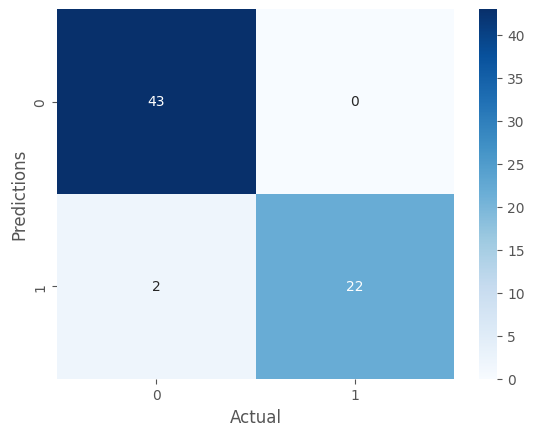

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues')
plt.xlabel('Actual')
plt.ylabel('Predictions')
plt.show()

In [ ]:
y_pred[:10]

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 1])

In [ ]:
y_prob = model.predict_proba(x_test)
y_prob[:,1]

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
roc_auc_score(y_test,y_prob[:,1])

np.float64(0.9583333333333333)

In [ ]:
fpr,tpr,_ = roc_curve(y_test,y_prob[:,1])

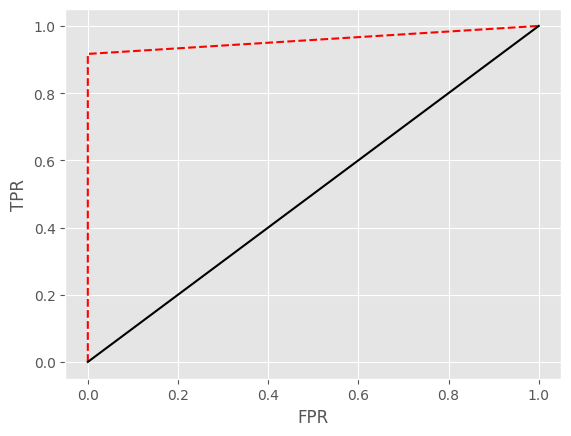

In [ ]:
plt.plot(fpr,tpr,ls = '--',color='r')
plt.plot([0,1],[0,1],color='k')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [ ]:
x.columns

Index(['age', 'sex', 'smoke', 'years', 'ldl', 'chp', 'height', 'weight', 'fh',
       'active', 'lifestyle', 'ihd', 'hr', 'dm', 'bpsys', 'bpdias', 'htn',
       'ivsd', 'ecgpatt', 'qwave', 'BMI', 'pulse_pressure', 'MAP',
       'smoke_exposure', 'ldl_age_ratio', 'ldl_smoke_interaction', 'obese',
       'bp_category', 'hr_risk', 'dm_ldl_interaction',
       'active_lifestyle_interaction', 'ivsd_risk', 'ecg_major_abnormal',
       'ecg_mild_abnormal', 'atherogenic_index', 'smoke_bpsys_interaction',
       'metabolic_syndrome_score'],
      dtype='object')

In [ ]:
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.0131618 , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.01068301, 0.        , 0.        , 0.83731846, 0.08594212,
       0.01410193, 0.        , 0.01246907, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.0263236 ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

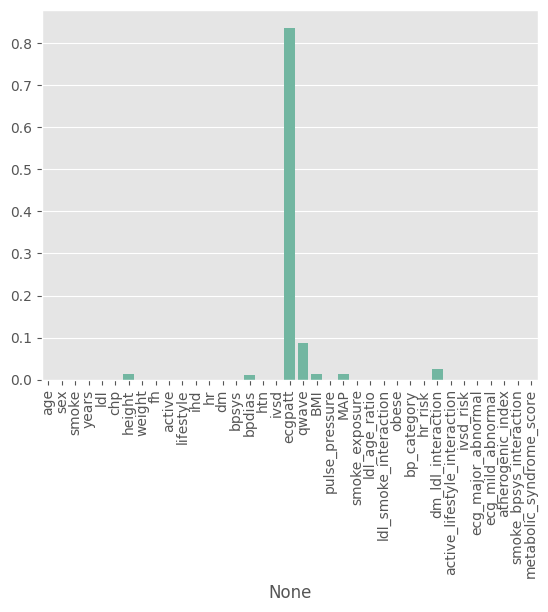

In [ ]:
sns.barplot(x = x.columns,y = model.feature_importances_)
plt.xticks(rotation=90)
plt.show()

In [ ]:
results = pd.DataFrame()
results['features'] = x.columns
results['importance'] = model.feature_importances_
results.sort_values(by='importance',ascending=False)

,features,importance
18,ecgpatt,0.837318
19,qwave,0.085942
29,dm_ldl_interaction,0.026324
20,BMI,0.014102
6,height,0.013162
22,MAP,0.012469
15,bpdias,0.010683
4,ldl,0.000000
1,sex,0.000000
0,age,0.000000


In [ ]:
imp_cols = results.sort_values(by='importance',ascending=False).head(7)['features'].values.tolist()
imp_cols

['ecgpatt', 'qwave', 'dm_ldl_interaction', 'BMI', 'height', 'MAP', 'bpdias']

In [ ]:
x = df[imp_cols]
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y)


model = DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
acc = accuracy_score(y_test,y_pred)
p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
mcc = matthews_corrcoef(y_test,y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

Accuracy: 0.9552
Precision: 1.0000
Recall: 0.8750
F1-Score: 0.9333
MCC: 0.9044


In [ ]:
confusion_matrix(y_test,y_pred)

array([[43,  0],
       [ 3, 21]])

In [ ]:
#save the data
df.to_csv('clean_data.csv',index = False)

In [ ]:
import pickle
with open('model_final.pkl','wb') as f:
  pickle.dump(model,f)


In [ ]:
with open('/content/model_final.pkl','rb') as f:
  loaded_model = pickle.load(f)

In [ ]:
loaded_model

DecisionTreeClassifier()

In [ ]:
df[imp_cols+['target']].sample(1)

,ecgpatt,qwave,dm_ldl_interaction,BMI,height,MAP,bpdias,target
19,3,0,0.0,32.961747,188,63.333333,50,1


In [ ]:
test = [[3	,0	,0.0	,32.961747,	188	,63.333333	,50]]
loaded_model.predict(test)

array([1])